# 04 — Baseline Models

Project: E-Waste Profitability Prediction
Group: 2026-AI-14
Module: IT3091 — Machine Learning

Regression baseline: Multiple Linear Regression
Classification baseline: Logistic Regression

Regression target: total_profit_usd
Classification target: Batch_Priority (profit-tier proxy)

Validation:
- Use the existing training/test split.
- Fit preprocessing inside each cross-validation training fold.
- Compare raw-only and engineered input sets using training CV.
- Preserve test data until model-selection decisions are recorded.

Libraries import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import platform
import sklearn

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.dummy import DummyRegressor, DummyClassifier

from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)

pd.set_option("display.max_columns", None)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15
scikit-learn: 1.6.1


Feature Engineering files upload

In [ ]:
uploaded = files.upload()

Saving train_features.csv to train_features.csv
Saving test_features.csv to test_features.csv
Saving feature_config.json to feature_config.json


In [ ]:
required_files = [
    "train_features.csv",
    "test_features.csv",
    "feature_config.json"
]

for filename in required_files:
    assert filename in uploaded, f"Missing file: {filename}"

train_df = pd.read_csv("train_features.csv")
test_df = pd.read_csv("test_features.csv")

with open("feature_config.json") as file:
    config = json.load(file)

print("Training dataset:", train_df.shape)
print("Test dataset:", test_df.shape)

Training dataset: (16000, 19)
Test dataset: (4000, 19)


Inputs and targets validate

In [ ]:
assert train_df["device_id"].is_unique
assert test_df["device_id"].is_unique

assert set(train_df["device_id"]).isdisjoint(
    set(test_df["device_id"])
)

all_features = config["feature_columns"]
raw_features = config["raw_feature_columns"]

forbidden_inputs = {
    "device_id",
    "item_name",
    "total_profit_usd",
    "Batch_Priority"
}

assert not set(all_features) & forbidden_inputs

X = train_df[all_features].copy()

y_reg = train_df["total_profit_usd"].copy()
y_cls = train_df["Batch_Priority"].copy()

assert np.isfinite(y_reg).all()
assert y_cls.notna().all()
assert set(y_cls.unique()) == {"Low", "Medium", "High"}

# Check that saved labels match the saved policy.
policy = config["priority_policy"]

expected_labels = np.where(
    y_reg <= policy["low_cutoff_usd"],
    "Low",
    np.where(
        y_reg <= policy["high_cutoff_usd"],
        "Medium",
        "High"
    )
)

assert np.array_equal(y_cls.to_numpy(), expected_labels)

print("Training inputs:", X.shape)
print("Consistency checks passed.")

Training inputs: (16000, 15)
Consistency checks passed.


Fold-local preprocessing pipeline

In [ ]:
def make_model_pipeline(model, selected_features):
    numeric = [
        column
        for column in config["numeric_features"]
        if column in selected_features
    ]

    categorical = [
        column
        for column in config["categorical_features"]
        if column in selected_features
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric),
        ("categorical", categorical_pipeline, categorical)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [ ]:
regression_cv = list(
    KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ).split(X, y_reg)
)

classification_cv = list(
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ).split(X, y_cls)
)

print("Regression folds:", len(regression_cv))
print("Classification folds:", len(classification_cv))

Regression folds: 5
Classification folds: 5


Dummy benchmarks evaluate

In [ ]:
dummy_reg_results = cross_validate(
    DummyRegressor(strategy="median"),
    X,
    y_reg,
    cv=regression_cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

dummy_cls_results = cross_validate(
    DummyClassifier(strategy="most_frequent"),
    X,
    y_cls,
    cv=classification_cv,
    scoring={
        "macro_f1": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
        "accuracy": "accuracy"
    }
)

dummy_summary = pd.DataFrame([
    {
        "task": "Regression",
        "model": "Median Dummy",
        "CV_MAE_USD": -dummy_reg_results["test_mae"].mean(),
        "CV_RMSE_USD": -dummy_reg_results["test_rmse"].mean(),
        "CV_R2": dummy_reg_results["test_r2"].mean()
    },
    {
        "task": "Classification",
        "model": "Most-Frequent Dummy",
        "CV_Macro_F1": dummy_cls_results["test_macro_f1"].mean(),
        "CV_Balanced_Accuracy": (
            dummy_cls_results["test_balanced_accuracy"].mean()
        ),
        "CV_Accuracy": dummy_cls_results["test_accuracy"].mean()
    }
])

display(dummy_summary)

dummy_summary.to_csv(
    "04_dummy_benchmarks.csv",
    index=False
)

,task,model,CV_MAE_USD,CV_RMSE_USD,CV_R2,CV_Macro_F1,CV_Balanced_Accuracy,CV_Accuracy
0,Regression,Median Dummy,7.578603,14.464028,-0.24474,NaN,NaN,NaN
1,Classification,Most-Frequent Dummy,NaN,NaN,NaN,0.166799,0.333333,0.333688


Linear Regression compare

In [ ]:
feature_sets = {
    "raw_only": raw_features,
    "with_engineered": all_features
}

regression_searches = {}
regression_comparison_rows = []

for name, selected_features in feature_sets.items():
    pipeline = make_model_pipeline(
        LinearRegression(),
        selected_features
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},  # OLS baseline has no tuning grid here.
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        refit="mae",
        cv=regression_cv,
        n_jobs=2,
        return_train_score=True,
        error_score="raise"
    )

    search.fit(X, y_reg)
    regression_searches[name] = search

    results = search.cv_results_
    index = search.best_index_

    regression_comparison_rows.append({
        "feature_set": name,
        "CV_MAE_USD": -results["mean_test_mae"][index],
        "CV_MAE_STD": results["std_test_mae"][index],
        "CV_RMSE_USD": -results["mean_test_rmse"][index],
        "CV_R2": results["mean_test_r2"][index],
        "Train_MAE_USD": -results["mean_train_mae"][index]
    })

regression_comparison = pd.DataFrame(
    regression_comparison_rows
).sort_values("CV_MAE_USD")

display(regression_comparison)

regression_comparison.to_csv(
    "04_regression_feature_comparison.csv",
    index=False
)

best_reg_feature_set = (
    regression_comparison.iloc[0]["feature_set"]
)

best_reg_search = regression_searches[
    best_reg_feature_set
]

best_reg_model = best_reg_search.best_estimator_

print("Selected regression features:", best_reg_feature_set)

,feature_set,CV_MAE_USD,CV_MAE_STD,CV_RMSE_USD,CV_R2,Train_MAE_USD
0,raw_only,1.989018,0.036475,3.166616,0.940318,1.986144
1,with_engineered,1.989817,0.036675,3.167295,0.940292,1.985912


Selected regression features: raw_only


Logistic Regression tune

In [ ]:
classification_searches = {}
classification_comparison_rows = []

for name, selected_features in feature_sets.items():
    pipeline = make_model_pipeline(
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),
        selected_features
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid={
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"]
        },
        scoring={
            "macro_f1": "f1_macro",
            "balanced_accuracy": "balanced_accuracy",
            "accuracy": "accuracy"
        },
        refit="macro_f1",
        cv=classification_cv,
        n_jobs=2,
        return_train_score=True,
        error_score="raise"
    )

    search.fit(X, y_cls)
    classification_searches[name] = search

    results = search.cv_results_
    index = search.best_index_

    classification_comparison_rows.append({
        "feature_set": name,
        "CV_Macro_F1": results["mean_test_macro_f1"][index],
        "CV_Macro_F1_STD": results["std_test_macro_f1"][index],
        "CV_Balanced_Accuracy": (
            results["mean_test_balanced_accuracy"][index]
        ),
        "CV_Accuracy": results["mean_test_accuracy"][index],
        "best_parameters": json.dumps(search.best_params_)
    })

    pd.DataFrame(results).to_csv(
        f"04_logistic_candidates_{name}.csv",
        index=False
    )

classification_comparison = pd.DataFrame(
    classification_comparison_rows
).sort_values("CV_Macro_F1", ascending=False)

display(classification_comparison)

classification_comparison.to_csv(
    "04_classification_feature_comparison.csv",
    index=False
)

best_cls_feature_set = (
    classification_comparison.iloc[0]["feature_set"]
)

best_cls_search = classification_searches[
    best_cls_feature_set
]

best_cls_model = best_cls_search.best_estimator_

print("Selected classification features:", best_cls_feature_set)
print("Selected parameters:", best_cls_search.best_params_)

,feature_set,CV_Macro_F1,CV_Macro_F1_STD,CV_Balanced_Accuracy,CV_Accuracy,best_parameters
0,raw_only,0.975771,0.003465,0.975751,0.97575,"{""model__C"": 10.0, ""model__class_weight"": null}"
1,with_engineered,0.972037,0.003398,0.972005,0.97200,"{""model__C"": 10.0, ""model__class_weight"": ""bal..."


Selected classification features: raw_only
Selected parameters: {'model__C': 10.0, 'model__class_weight': None}


In [ ]:
C = 10.0
class_weight = None
feature_set = "raw_only"

Logistic Regression using raw features achieved a mean five-fold cross-validation macro-F1 of 0.975771, compared with 0.972037 using engineered features. The raw-only configuration was selected because it achieved a slightly higher score with fewer inputs. The selected parameters were C = 10.0 and class_weight = None. These results evaluate prediction of derived profit tiers, rather than independently verified operational priorities. Final held-out test evaluation remains pending.

Fold results of selected models

In [ ]:
reg_results = best_reg_search.cv_results_
reg_index = best_reg_search.best_index_

regression_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE_USD": [
        -reg_results[f"split{i}_test_mae"][reg_index]
        for i in range(5)
    ],
    "RMSE_USD": [
        -reg_results[f"split{i}_test_rmse"][reg_index]
        for i in range(5)
    ],
    "R2": [
        reg_results[f"split{i}_test_r2"][reg_index]
        for i in range(5)
    ]
})

cls_results = best_cls_search.cv_results_
cls_index = best_cls_search.best_index_

classification_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Macro_F1": [
        cls_results[f"split{i}_test_macro_f1"][cls_index]
        for i in range(5)
    ],
    "Balanced_Accuracy": [
        cls_results[f"split{i}_test_balanced_accuracy"][cls_index]
        for i in range(5)
    ],
    "Accuracy": [
        cls_results[f"split{i}_test_accuracy"][cls_index]
        for i in range(5)
    ]
})

display(regression_fold_results)
display(classification_fold_results)

regression_fold_results.to_csv(
    "04_regression_cv_folds.csv",
    index=False
)

classification_fold_results.to_csv(
    "04_classification_cv_folds.csv",
    index=False
)

,Fold,MAE_USD,RMSE_USD,R2
0,1,1.979734,3.155737,0.942799
1,2,1.935059,3.060252,0.943518
2,3,2.019087,3.223376,0.937536
3,4,1.972439,3.086302,0.940914
4,5,2.038769,3.307414,0.936825


,Fold,Macro_F1,Balanced_Accuracy,Accuracy
0,1,0.975341,0.975316,0.975313
1,2,0.977188,0.977191,0.977187
2,3,0.969707,0.969685,0.969688
3,4,0.976288,0.976249,0.976250
4,5,0.980332,0.980311,0.980313


Across five-fold cross-validation, Linear Regression achieved a mean MAE of USD 1.9890, RMSE of USD 3.1666, and R² of 0.9403. Performance varied only modestly across folds. However, prediction errors may be substantial relative to the profit of low-value items. Logistic Regression achieved a mean macro-F1 of 0.975771 and accuracy of 97.575% for the derived profit-tier labels. These are model-selection CV results; held-out test evaluation remains pending.


Linear model residual diagnostics

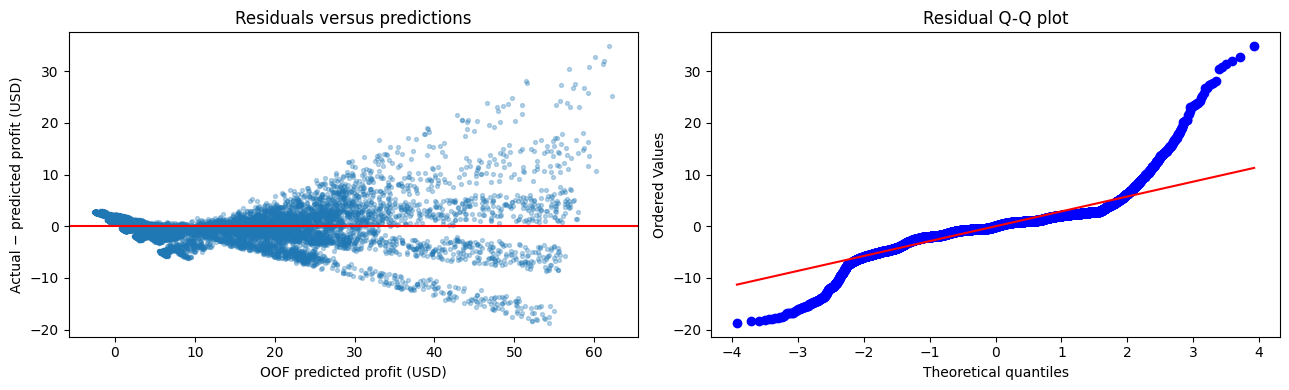

Mean residual USD: -0.0007
Negative OOF predictions: 2603


In [ ]:
from scipy.stats import probplot

oof_predictions = cross_val_predict(
    best_reg_model,
    X,
    y_reg,
    cv=regression_cv,
    n_jobs=2
)

residuals = y_reg.to_numpy() - oof_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(
    oof_predictions,
    residuals,
    s=8,
    alpha=0.3
)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("OOF predicted profit (USD)")
axes[0].set_ylabel("Actual − predicted profit (USD)")
axes[0].set_title("Residuals versus predictions")

probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Residual Q-Q plot")

plt.tight_layout()
plt.savefig("04_residual_diagnostics.png", dpi=150)
plt.show()

print("Mean residual USD:", round(residuals.mean(), 4))
print(
    "Negative OOF predictions:",
    int((oof_predictions < 0).sum())
)

oof_diagnostics = pd.DataFrame({
    "device_id": train_df["device_id"],
    "actual_profit_usd": y_reg,
    "oof_predicted_profit_usd": oof_predictions,
    "residual_usd": residuals,
    "absolute_error_usd": np.abs(residuals)
})

oof_diagnostics.to_csv(
    "04_training_oof_diagnostics.csv",
    index=False
)

The mean out-of-fold residual was approximately −0.0007 USD, indicating little overall average bias. However, the residual plot showed increasing error spread with predicted profit, suggesting heteroscedasticity. The Q-Q plot showed substantial tail departures from normality. Additionally, 2,603 of 16,000 out-of-fold predictions (16.27%) were negative despite positive recorded targets. These findings support retaining Linear Regression as a benchmark while comparing nonlinear alternatives. Negative predictions were not automatically clipped.

Results

In [ ]:
model_summary = {
    "notebook": "04_Linear_Regression_Logistic_Regression",
    "regression_model": "LinearRegression",
    "classification_model": "LogisticRegression",
    "regression_feature_set": best_reg_feature_set,
    "classification_feature_set": best_cls_feature_set,
    "regression_features": feature_sets[best_reg_feature_set],
    "classification_features": feature_sets[best_cls_feature_set],
    "regression_cv_mae_usd": float(-best_reg_search.best_score_),
    "classification_cv_macro_f1": float(best_cls_search.best_score_),
    "classification_parameters": best_cls_search.best_params_,
    "test_evaluated": False,
    "priority_meaning": "Profit-tier proxy",
    "sklearn_version": sklearn.__version__
}

with open("04_model_summary.json", "w") as file:
    json.dump(model_summary, file, indent=2)

joblib.dump(
    best_reg_model,
    "04_linear_profit_pipeline.joblib"
)

joblib.dump(
    best_cls_model,
    "04_logistic_priority_pipeline.joblib"
)

print("Baseline models and CV evidence saved.")
print("Test evaluation has not been performed.")

Baseline models and CV evidence saved.
Test evaluation has not been performed.


## Baseline interpretation

### Regression
- Selected feature set:
- Mean CV MAE:
- Mean CV RMSE:
- Mean CV R²:
- Improvement over the median dummy:
- Residual patterns:
- Negative prediction count:

### Classification
- Selected feature set:
- Selected C and class weighting:
- Mean CV macro-F1:
- Mean CV balanced accuracy:
- Improvement over the most-frequent dummy:

### Limitations
- CV scores were used for model selection.
- Priority labels are derived profit tiers.
- Classifier CV is conditional on thresholds learned from
  the full training targets.
- Metal-yield availability before the decision needs confirmation.
- Final test evaluation is pending.

### AI-use declaration
Describe the AI assistance actually used, the code/results
verified by the student, and the student's own contribution.

Models and evidance download


In [ ]:
files.download("04_model_summary.json")
files.download("04_regression_cv_folds.csv")
files.download("04_classification_cv_folds.csv")

files.download("04_linear_profit_pipeline.joblib")
files.download("04_logistic_priority_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_df.to_csv("04_train_features.csv", index=False)
test_df.to_csv("04_test_features.csv", index=False)

files.download("04_train_features.csv")
files.download("04_test_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>